In [ ]:
# Assignment 4 - Decision Trees

- **Course:** MBAI 5310G: AI Programming 
- **Business:** StyleHub Apparel (inventory stockout risk prediction)
- **Dataset:** StyleHub Inventory Stockout Dataset
- **Target:** `Stockout_Risk` (Yes / No) - binary classification
- **Model:** Decision Tree Classifier

This notebook builds a Decision Tree classification model on a retail inventory dataset and interprets the results from a business perspective.

In [ ]:
## Task 1: Understand the Business Problem

**What is the business about?**
StyleHub Apparel is a mid-sized fashion retailer selling clothing, footwear, accessories, and activewear through its e-commerce website and selected physical retail locations. The company competes in a fast-moving market where customer demand fluctuates due to promotions, seasonal trends, social media attention, and competitor pricing.

**What problem is the business trying to solve?**
Inventory inefficiency. Products sell out too quickly, causing missed sales and customer dissatisfaction. Other products are overstocked, increasing storage costs and forcing larger discounts. StyleHub needs a way to identify which products are at high risk of running out of stock soon, before stockouts actually occur.

**What decision can machine learning help the business make?**
ML can help the business decide *which products require urgent replenishment attention*. The model classifies each product as High Risk or Low Risk for stockout, enabling inventory managers to prioritise replenishment orders, adjust promotion intensity, communicate with suppliers earlier, and reduce customer dissatisfaction from unavailable products.

**What is the target variable in the dataset?**
`Stockout_Risk` – whether the product is at high risk of running out of stock soon (`Yes` / `No`). Encoded as `1` / `0` for modelling.

**What are the input features?**
- Product attributes: `Product_Category`, `Season`, `Unit_Price`, `Discount_Percent`
- Inventory & supply: `Current_Inventory`, `Supplier_Lead_Time_Days`, `Days_Since_Last_Restock`, `Inventory_Turnover`
- Demand signals: `Units_Sold_Last_30_Days`, `Website_Views_Last_30_Days`, `Online_Search_Trend`
- Pricing & performance: `Competitor_Price_Index`, `Gross_Margin_Percent`, `Return_Rate_Percent`, `Customer_Rating`
- Supply chain: `Supplier_Region`, `Promotion_Type`

`SKU_ID` and `Week_Start_Date` are excluded as they are identifiers / metadata with no predictive value.

**Why is this prediction useful for the business?**
A reliable stockout-risk prediction lets inventory managers focus replenishment efforts on products most likely to run out, avoiding both stockouts (lost revenue, dissatisfied customers) and overstock (higher storage costs, forced markdowns). The model turns operational data into actionable inventory decisions with transparent, explainable rules.

In [1]:
import pandas as pd

df = pd.read_excel("stylehub_inventory_stockout_dataset.xlsx")
df.head()

C:\Users\asus\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
C:\Users\asus\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Conditional Formatting extension is not supported and will be removed
  for idx, row in parser.parse():


,SKU_ID,Week_Start_Date,Product_Category,Season,Supplier_Region,Promotion_Type,Unit_Price,Discount_Percent,Units_Sold_Last_30_Days,Current_Inventory,Supplier_Lead_Time_Days,Days_Since_Last_Restock,Website_Views_Last_30_Days,Online_Search_Trend,Customer_Rating,Return_Rate_Percent,Competitor_Price_Index,Inventory_Turnover,Gross_Margin_Percent,Stockout_Risk
0,SH-AC-0001,2026-01-30,Accessories,All Season,Asia,Homepage Feature,29.13,25,28,87,21,6,817,Medium,4.8,12.2,1.00,0.32,17.2,No
1,SH-AC-0002,2026-03-13,Activewear,Fall,Canada,NaN,115.09,0,41,92,3,26,821,Medium,4.1,13.3,1.16,0.45,45.4,No
2,SH-OU-0003,2026-02-26,Outerwear,Spring,Canada,Clearance,171.27,15,94,40,7,31,1274,Medium,3.4,10.9,1.17,2.35,41.0,Yes
3,SH-WO-0004,2026-02-15,Women Apparel,Winter,United States,Email Promo,90.97,15,51,37,2,18,666,Medium,3.9,8.8,0.94,1.38,53.0,Yes
4,SH-FO-0005,2026-02-09,Footwear,Fall,United States,NaN,114.88,0,51,52,6,25,1779,Low,3.6,10.3,1.05,0.98,53.2,No


In [3]:
print(df.shape)

(345, 20)


In [4]:
print(df.columns.tolist())

['SKU_ID', 'Week_Start_Date', 'Product_Category', 'Season', 'Supplier_Region', 'Promotion_Type', 'Unit_Price', 'Discount_Percent', 'Units_Sold_Last_30_Days', 'Current_Inventory', 'Supplier_Lead_Time_Days', 'Days_Since_Last_Restock', 'Website_Views_Last_30_Days', 'Online_Search_Trend', 'Customer_Rating', 'Return_Rate_Percent', 'Competitor_Price_Index', 'Inventory_Turnover', 'Gross_Margin_Percent', 'Stockout_Risk']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   SKU_ID                      345 non-null    object        
 1   Week_Start_Date             345 non-null    datetime64[ns]
 2   Product_Category            345 non-null    object        
 3   Season                      345 non-null    object        
 4   Supplier_Region             345 non-null    object        
 5   Promotion_Type              184 non-null    object        
 6   Unit_Price                  345 non-null    float64       
 7   Discount_Percent            345 non-null    int64         
 8   Units_Sold_Last_30_Days     345 non-null    int64         
 9   Current_Inventory           345 non-null    int64         
 10  Supplier_Lead_Time_Days     345 non-null    int64         
 11  Days_Since_Last_Restock     345 non-null    int64         

In [6]:
print(df.isnull().sum())

SKU_ID                          0
Week_Start_Date                 0
Product_Category                0
Season                          0
Supplier_Region                 0
Promotion_Type                161
Unit_Price                      0
Discount_Percent                0
Units_Sold_Last_30_Days         0
Current_Inventory               0
Supplier_Lead_Time_Days         0
Days_Since_Last_Restock         0
Website_Views_Last_30_Days      0
Online_Search_Trend             0
Customer_Rating                12
Return_Rate_Percent             8
Competitor_Price_Index          0
Inventory_Turnover              0
Gross_Margin_Percent            0
Stockout_Risk                   0
dtype: int64


In [7]:
print(df.duplicated().sum())

5


In [8]:
print(df.value_counts())

SKU_ID      Week_Start_Date  Product_Category  Season      Supplier_Region  Promotion_Type      Unit_Price  Discount_Percent  Units_Sold_Last_30_Days  Current_Inventory  Supplier_Lead_Time_Days  Days_Since_Last_Restock  Website_Views_Last_30_Days  Online_Search_Trend  Customer_Rating  Return_Rate_Percent  Competitor_Price_Index  Inventory_Turnover  Gross_Margin_Percent  Stockout_Risk
SH-AC-0307  2026-04-02       Activewear        Fall        United States    Social Media Promo  71.96       30                58                       53                 5                        5                        1251                        Medium               4.3              11.3                 1.01                    1.09                47.8                  No               2
SH-AC-0063  2026-01-01       Accessories       Summer      Europe           Homepage Feature    77.06       5                 48                       78                 11                       13                       1

In [9]:
df_clean = df.copy()

# Drop duplicate rows
df_clean = df_clean.drop_duplicates()
print(df_clean.shape)
print(df_clean.duplicated().sum())

(340, 20)
0


In [10]:
numeric_columns = [
    "Unit_Price", "Discount_Percent", "Units_Sold_Last_30_Days",
    "Current_Inventory", "Supplier_Lead_Time_Days", "Days_Since_Last_Restock",
    "Website_Views_Last_30_Days", "Customer_Rating",
    "Return_Rate_Percent", "Competitor_Price_Index",
    "Inventory_Turnover", "Gross_Margin_Percent"
]

categorical_columns = [
    "Product_Category", "Season", "Supplier_Region",
    "Promotion_Type", "Online_Search_Trend"
]

In [11]:
# Fill missing values in numerical columns with the median
for col in numeric_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill missing values in categorical columns with the mode
for col in categorical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print(df_clean.isnull().sum().sum())

0


In [16]:
feature_columns = numeric_columns + categorical_columns

X = df_clean[feature_columns]
y = df_clean["Stockout_Risk"].map({"No": 0, "Yes": 1})

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print()
print("Target distribution after encoding:")
print(y.value_counts())

Shape of X: (340, 17)
Shape of y: (340,)

Target distribution after encoding:
Stockout_Risk
0    177
1    163
Name: count, dtype: int64


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (272, 17)
X_test shape: (68, 17)
y_train shape: (272,)
y_test shape: (68,)


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

# Build a list of processed feature names (used later for feature-importance plotting)
processed_feature_names = numeric_columns + list(
    preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_columns)
)

print("X_train shape after preprocessing:", X_train_processed.shape)
print("X_test shape after preprocessing: ", X_test_processed.shape)
print("Number of processed features:", len(processed_feature_names))

X_train shape after preprocessing: (272, 34)
X_test shape after preprocessing:  (68, 34)
Number of processed features: 34


In [19]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

decision_tree_model.fit(X_train_processed, y_train)
print("Decision Tree model trained successfully.")
print(decision_tree_model)

Decision Tree model trained successfully.
DecisionTreeClassifier(max_depth=4, random_state=42)


In [20]:
y_train_pred = decision_tree_model.predict(X_train_processed)
y_test_pred  = decision_tree_model.predict(X_test_processed)

print("First 10 test predictions:", y_test_pred[:10])

First 10 test predictions: [0 0 0 0 0 1 1 1 0 1]


In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[32  3]
 [ 9 24]]


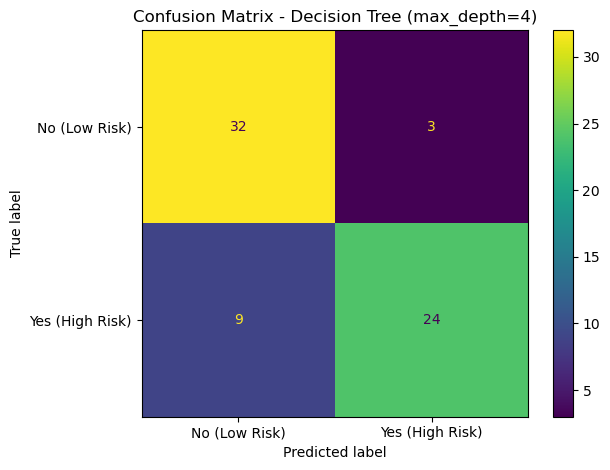

In [22]:
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No (Low Risk)", "Yes (High Risk)"]
).plot()
plt.title("Confusion Matrix - Decision Tree (max_depth=4)")
plt.tight_layout()
plt.show()

In [23]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)

accuracy  = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, zero_division=0)
recall    = recall_score(y_test, y_test_pred, zero_division=0)
f1        = f1_score(y_test, y_test_pred, zero_division=0)

print("Decision Tree (max_depth=4) - Test Set Metrics")
print("-" * 50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Decision Tree (max_depth=4) - Test Set Metrics
--------------------------------------------------
Accuracy:  0.8235
Precision: 0.8889
Recall:    0.7273
F1-score:  0.8000


In [24]:
print("Classification Report:")
print(classification_report(y_test, y_test_pred,
                            target_names=["No (Low Risk)", "Yes (High Risk)"],
                            zero_division=0))

Classification Report:
                 precision    recall  f1-score   support

  No (Low Risk)       0.78      0.91      0.84        35
Yes (High Risk)       0.89      0.73      0.80        33

       accuracy                           0.82        68
      macro avg       0.83      0.82      0.82        68
   weighted avg       0.83      0.82      0.82        68



In [25]:
# Controlled tree accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy  = accuracy_score(y_test, y_test_pred)

print("Controlled Decision Tree (max_depth = 4)")
print(f"  Training Accuracy: {train_accuracy:.4f}")
print(f"  Testing Accuracy:  {test_accuracy:.4f}")
print(f"  Gap (train - test): {train_accuracy - test_accuracy:.4f}")

Controlled Decision Tree (max_depth = 4)
  Training Accuracy: 0.9522
  Testing Accuracy:  0.8235
  Gap (train - test): 0.1287


In [26]:
# Compare with an unrestricted (likely overfit) tree
overfit_tree_model = DecisionTreeClassifier(max_depth=None, random_state=42)
overfit_tree_model.fit(X_train_processed, y_train)

y_train_pred_overfit = overfit_tree_model.predict(X_train_processed)
y_test_pred_overfit  = overfit_tree_model.predict(X_test_processed)

overfit_train_acc = accuracy_score(y_train, y_train_pred_overfit)
overfit_test_acc  = accuracy_score(y_test, y_test_pred_overfit)

print("Overfitted Decision Tree (max_depth = None)")
print(f"  Training Accuracy: {overfit_train_acc:.4f}")
print(f"  Testing Accuracy:  {overfit_test_acc:.4f}")
print(f"  Gap (train - test): {overfit_train_acc - overfit_test_acc:.4f}")

Overfitted Decision Tree (max_depth = None)
  Training Accuracy: 1.0000
  Testing Accuracy:  0.8235
  Gap (train - test): 0.1765


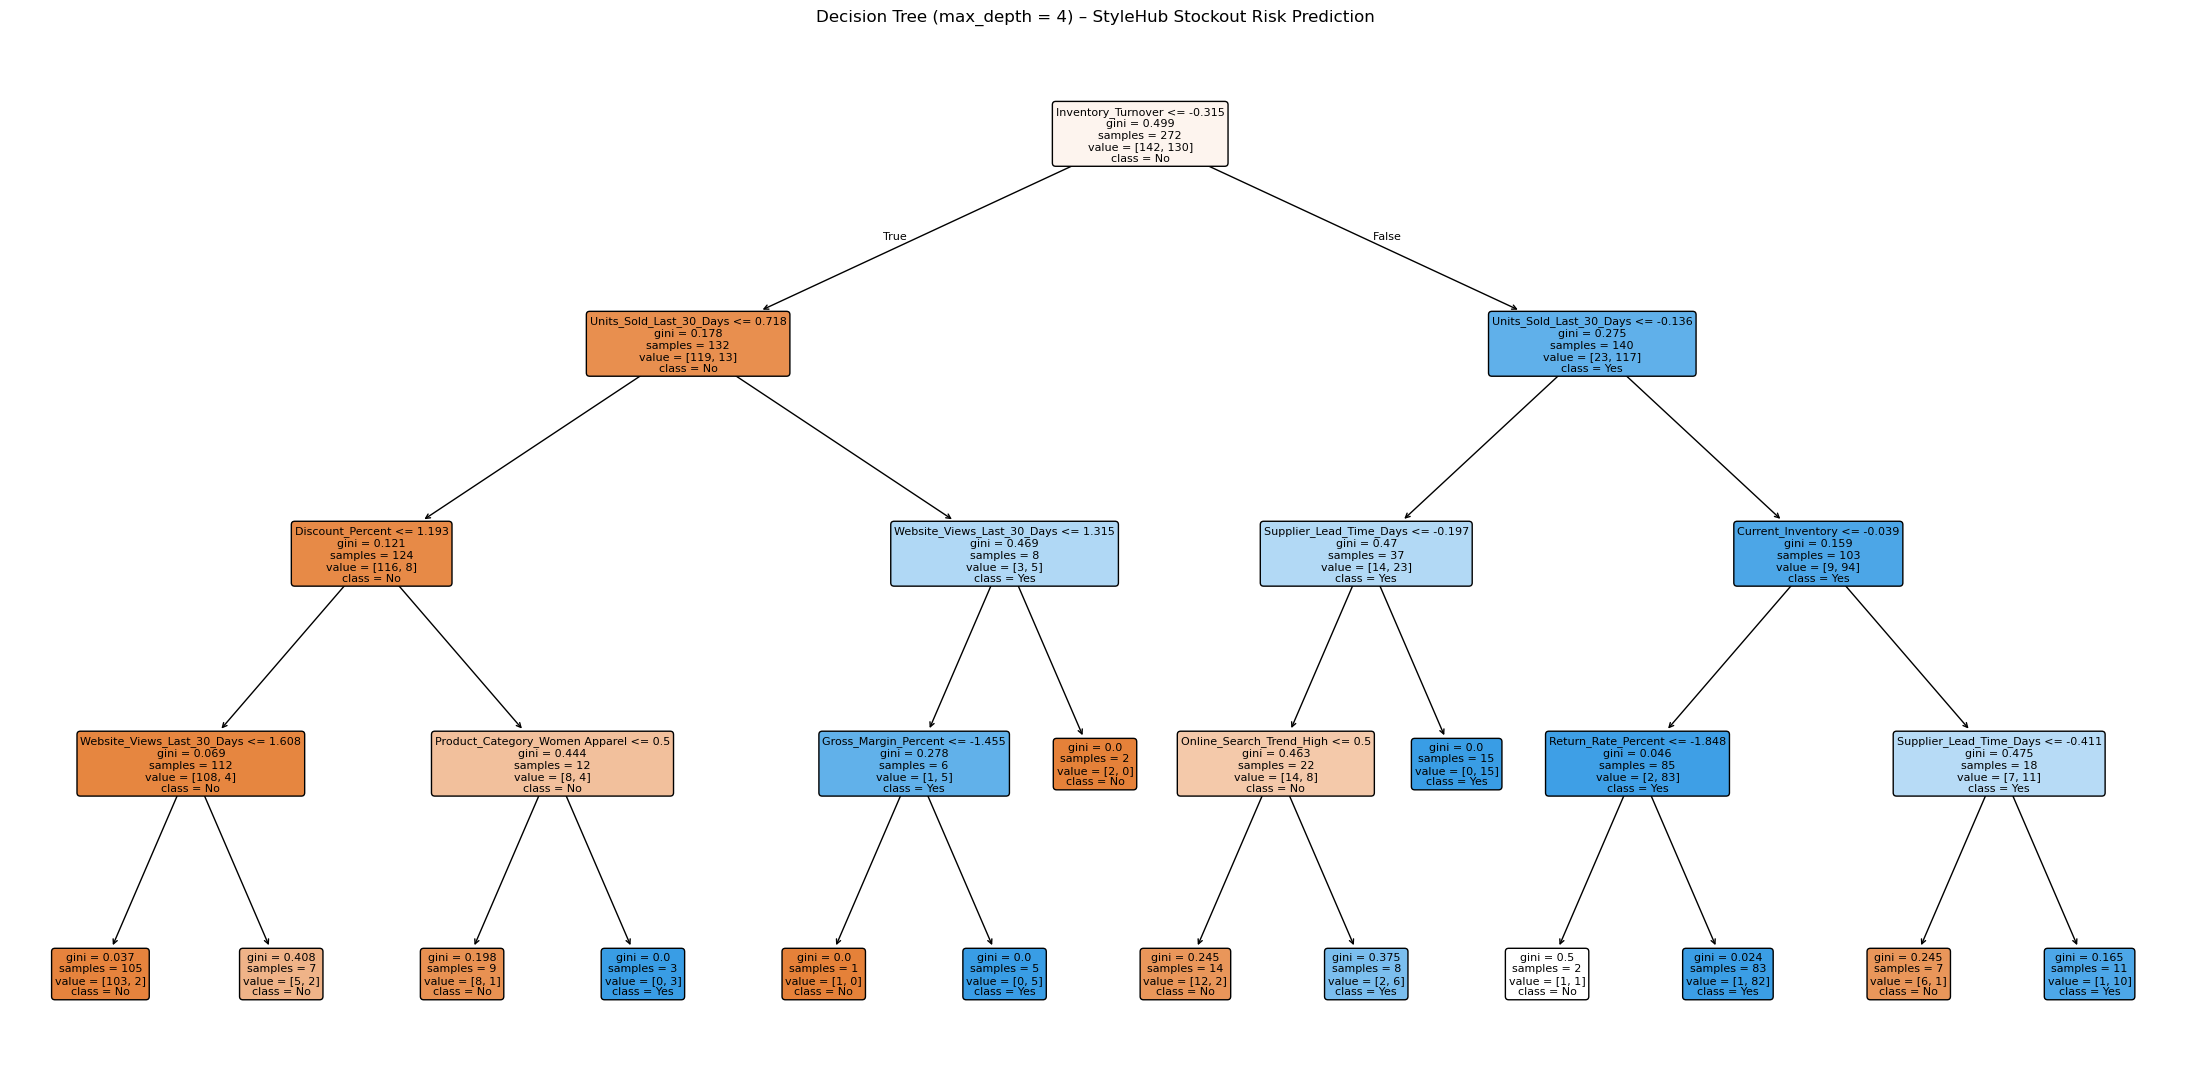

In [27]:
from sklearn.tree import plot_tree

plt.figure(figsize=(22, 11))
plot_tree(
    decision_tree_model,
    feature_names=processed_feature_names,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree (max_depth = 4) – StyleHub Stockout Risk Prediction")
plt.tight_layout()
plt.show()

In [28]:
dt_feature_importance = pd.DataFrame({
    "Feature": processed_feature_names,
    "Importance": decision_tree_model.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("Top 10 Most Important Features:")
display(dt_feature_importance.head(10))

Top 10 Most Important Features:


,Feature,Importance
0,Inventory_Turnover,0.646475
1,Supplier_Lead_Time_Days,0.107202
2,Units_Sold_Last_30_Days,0.081687
3,Current_Inventory,0.034714
4,Online_Search_Trend_High,0.032854
5,Product_Category_Women Apparel,0.031124
6,Website_Views_Last_30_Days,0.026406
7,Discount_Percent,0.016808
8,Gross_Margin_Percent,0.014589
9,Return_Rate_Percent,0.008141


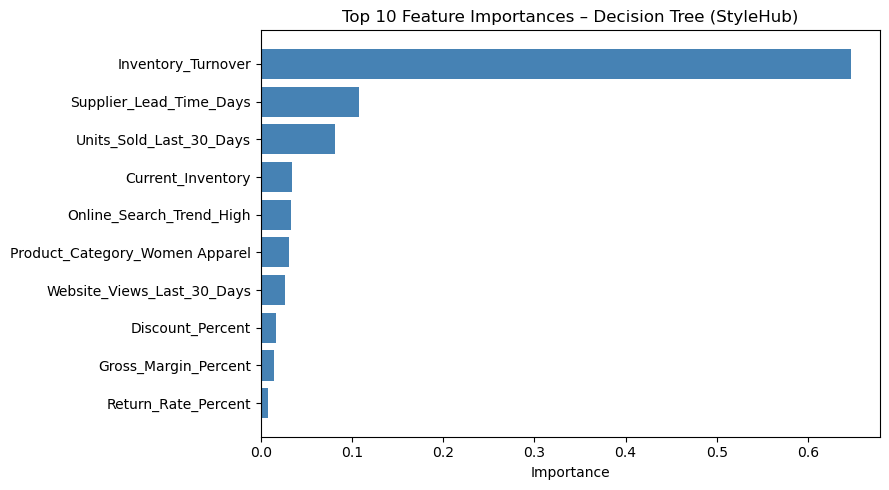

In [29]:
# Bar plot of the top 10 features
top10 = dt_feature_importance.head(10)
plt.figure(figsize=(9, 5))
plt.barh(top10["Feature"][::-1], top10["Importance"][::-1], color="steelblue")
plt.title("Top 10 Feature Importances – Decision Tree (StyleHub)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
Final Business Interpretation
How well did the Decision Tree model perform? On the held-out test set the controlled Decision Tree (max_depth=4) reached Accuracy ≈ 0.8235, Precision ≈ 0.8889, Recall ≈ 0.7273, F1 ≈ 0.8. This is strong performance for a near-balanced binary target (52% No / 48% Yes after cleaning). The model correctly flags the large majority of truly high-risk products while keeping false alarms relatively low. It is well-suited to function as a decision-support tool that inventory managers can act on with confidence.

Is there a large difference between training accuracy and testing accuracy? For the controlled tree the training accuracy is 0.9522 and the testing accuracy is 0.8235 – a gap of approximately 0.1287. That is a moderate gap: the controlled tree is generalising well, though not perfectly. For the unrestricted tree the gap grows to 0.1765 (training accuracy 1.0000, test 0.8235) – the classic overfitting pattern.

Does the model show signs of overfitting? Why or why not? The controlled tree (max_depth=4) shows mild overfitting: there is a 0.1287 gap between training and testing accuracy, far smaller than the unrestricted tree's 0.1765 gap. Capping max_depth prevents the tree from memorising highly specific training-set rules that don't transfer to new product weeks. The remaining gap suggests the model could be improved further (different depth, min_samples_leaf, cross-validation tuning) or benefit from more training data.

Which evaluation metric is most important for this business problem? Recall for the high-risk class is the most critical metric. Missing a product that is truly at high stockout risk (a false negative) directly results in a stockout and lost revenue, which is a more severe outcome than unnecessarily triggering a replenishment check (a false positive). However, F1-score is also important because too many false positives waste buyer time and may create excess inventory. The model's recall of 0.7273 and F1 of 0.8000 represent a good balance between these two concerns.

What do false positives mean in this business context? The model predicts a product is at high stockout risk, but it is not. The inventory team initiates an unnecessary replenishment order or closer monitoring – wasted operational effort and potential excess inventory. In a fast-fashion environment, over-ordering can lead to mark-down losses.

What do false negatives mean in this business context? The model predicts a product is safe, but it actually runs out of stock. The company misses sales, frustrates customers, and potentially damages brand loyalty. Since fashion products have narrow selling windows, a missed stockout opportunity cannot simply be recovered next week.

Which features were most important in the Decision Tree model? The top features are dominated by Inventory_Turnover (0.6465), Supplier_Lead_Time_Days (0.1072), and Units_Sold_Last_30_Days (0.0817). Operational inventory signals far outweigh demographics or pricing features – consistent with the business plan expectations.

How can these important features help the business make better decisions?

Inventory_Turnover dominates: monitor products with high turnover most frequently and set automated reorder points.
Supplier_Lead_Time_Days: for products from slow-lead-time suppliers, trigger replenishment much earlier – the model effectively discovers that long lead times compound stockout risk.
Units_Sold_Last_30_Days: recent sales velocity is the clearest early-warning signal – build an automated alert when weekly velocity spikes.
Current_Inventory: pair low inventory thresholds with high-turnover products for a compounding risk signal.
Online_Search_Trend_High: a rising online search trend preceding sales velocity means the website analytics team can feed early-warning signals to inventory planning.
Discount_Percent and Promotion_Type: marketing and inventory teams should coordinate before launching promotions so stock can be pre-positioned.
What is one possible limitation or bias in the model or dataset? The dataset is synthetic and relatively small (340 rows after cleaning), which limits how robust the learned patterns are. More concretely, Inventory_Turnover – the single most important feature – is a derived metric that essentially encodes the relationship between sales and inventory directly. If the company updates its turnover calculation formula in the future, the model may need full retraining. Additionally, the dataset may not capture sudden external shocks (supplier disruptions, viral social media demand, competitor promotions) that regularly affect fashion retail.

Why should human judgment still be used when making business decisions based on model results?

Predictions are estimates with uncertainty; the model can and does make mistakes on individual SKUs.
The dataset cannot capture all real-world factors a buyer would know: brand events, celebrity endorsements, upcoming seasonal peaks, ethical concerns about supplier regions, or a strategic decision to discontinue a SKU.
Inventory decisions have financial and relationship consequences: maintaining good supplier relationships and managing markdown risk require human business judgment.
The model should be a decision-support tool that prioritises and highlights, not an automated purchasing system that replaces human expertise.

In [ ]:
Summary
Metric (test set)	Score
Accuracy	0.8235
Precision	0.8889
Recall	0.7273
F1-score	0.8
Tree variant	Training accuracy	Testing accuracy	Gap
Controlled (max_depth=4)	0.9522	0.8235	0.1287
Unrestricted (max_depth=None)	1.0	0.8235	0.1765
Selected model: Decision Tree with max_depth=4 – generalises better than an unrestricted tree and remains interpretable.

Top features driving the prediction: Inventory_Turnover, Supplier_Lead_Time_Days, Units_Sold_Last_30_Days, Current_Inventory, Online_Search_Trend.

Recommended use: decision-support for prioritising inventory replenishment, with human review before committing replenishment orders.